#### `HeisenBugs` : Because of chance, some problems in probability occur by-chance that cannot be debugged, because they were occured by-chance and thus we cannot reproduce such problems again for debugging.
`Solution` : We make the output predictable.

#### `pseudo-randomness` : take some input from real world( like from a sensor ) called as `seed`, then perform some operations on it to get a random number as an output. 
`seed` : is the true random taken from real world.
We can make the chance or output predictable if we set the seed ourself. >>>Like `np.random.seed(0)`

In [1]:
import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns
sns.set(color_codes = True)
sns.set_style("white")

import numpy as np

## There are two Questions in Probability (quantifying chances) :
1) What are the chances that the coin will land on its head ?  0.5 (Easy)
2) if i flip it n times , how many will be heads ?  answer will come after experiment. (Hard)

The Experiment in this notebook.ipynb will explain the 2nd Question.


In [2]:
np.random.uniform(low=0.0,high=1.0) #generate a random number btw 0 and 1.

0.2846727839233364

In [3]:
#generate a 'flip'

def flip(num = 1):
    flips = []

    for i in range(num):
        num = np.random.uniform(low = 0.0 , high = 1.0 )
        if num > 0.5:
            flips.append('H')         #doing yield here : generators concept.
        else:
            flips.append('T')

    return flips

In [4]:
flip()

['H']

In [5]:
flips  = flip(10)
print(flips)

['H', 'T', 'T', 'H', 'T', 'T', 'H', 'H', 'T', 'H']


In [6]:
values , counts = np.unique(flips,return_counts = True)    #returns values and their counts : numpy function.

In [7]:
values , counts         #Try only values or counts : The returned values by numpy are stored in two variables.

(array(['H', 'T'], dtype='<U1'), array([5, 5]))

# Probability of flips

In [8]:
from collections import Counter , defaultdict

def get_freqs(flips):
    keys = Counter(flips).keys()
    values = Counter(flips).values()

    # print(keys)
    # print(values)

    # return dict(zip(keys,values))                       # bug! : what if there is no "H" or "T".
                                                          #In dictionary if we do not have a key and try to search the key : it gives KeyERROR. 
    return defaultdict(int,dict(zip(keys,values)))

In [9]:
freqs = get_freqs(flips)
print(freqs)

defaultdict(<class 'int'>, {'H': 5, 'T': 5})


In [10]:
prob_h = freqs["H"] / len(flips)      #basic probability formula
print(prob_h)

0.5


## Experiment : Prob calculated based on 1 flip upto N flips

In [11]:
maximum_flips = 1000 

probs = []

for num_flips in range(1,maximum_flips):             #we are flipping this coin thousad times.We are flipping it like this...
    flips = flip(num_flips)                          #first time 1 flip , 2nd time 2 flips ,3rd time 3 flips ... 1000th time 1000 flips.
    freqs = get_freqs(flips)
    prob_h = freqs["H"]/ len(flips)

    probs.append(prob_h)

In [12]:
print(freqs)

defaultdict(<class 'int'>, {'H': 469, 'T': 530})


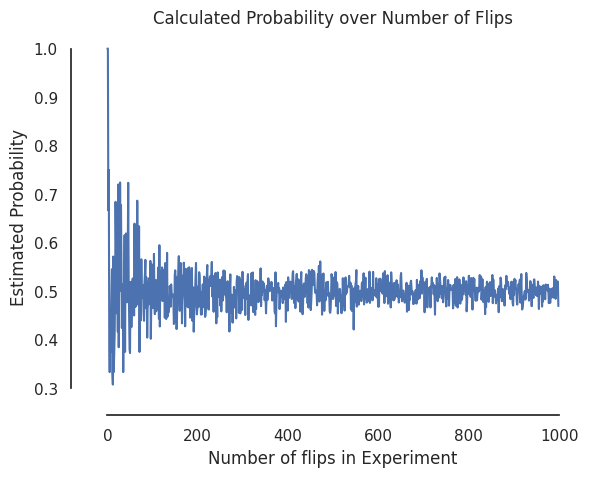

In [13]:
plt.plot(probs)

plt.xlabel("Number of flips in Experiment")
plt.ylabel("Estimated Probability")
plt.title("Calculated Probability over Number of Flips")
sns.despine(offset=10,trim=True)
plt.show()

#### Check some first and some last values of Graph

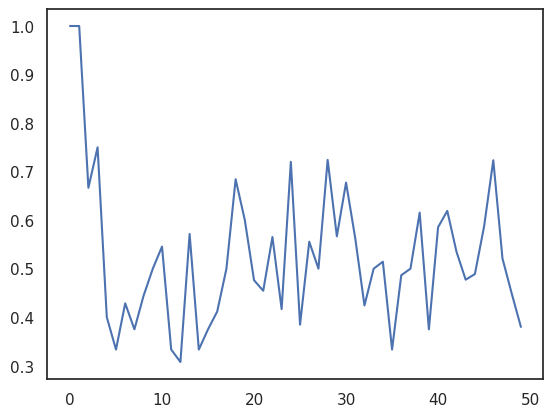

In [14]:
plt.plot(probs[:50])                         #First 50 values : When we flip the coin 1st time and there is only one flip the probability of head is 100% in this case.  

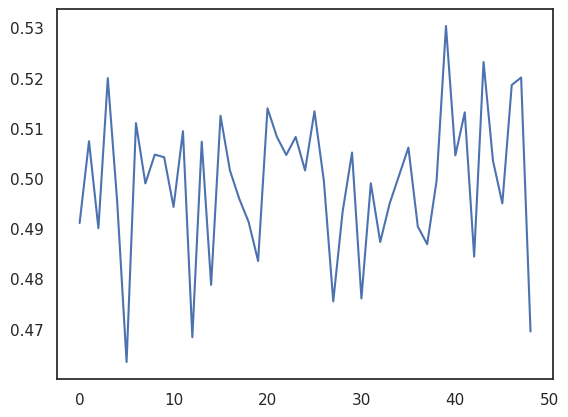

In [15]:
plt.plot(probs[maximum_flips-50:])              #last 50 values : They are occilating around 0.5

# `Bokeh` for Interactive Plots

In [16]:
from bokeh.plotting import figure , show , output_notebook

output_notebook()

Loading BokehJS ...

In [17]:
p = figure(title = "Simple line plot in Bokeh",
           x_axis_label = "Number of flips in Experiment",
           y_axis_label = "Estimated Probability",
           width = 580, height = 380)

In [18]:
# Convert the range to a list
x = list(range(1, maximum_flips))


p.line(x=x, y=probs, line_width=2, color="navy")

show(p)